In [ ]:
#basic import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset
df = pd.read_csv('data.csv')
df.head()

,Unnamed: 0,X53416,M83670,X90908,M97496,X90908.1,U37019,R48602,T96548,X64559,...,H87456,R64130,H11125.1,U22055,L22524,M13699.1,X54489,T55008,M10065.2,y
0,0,70,-81,25,10,22,113,36,163,9,...,75,5,68,138,53,-4,123,2,19,tumor
1,1,108,-30,-7,60,0,24,8,113,-3,...,186,6,60,93,140,-3,271,-1,-51,tumor
2,2,75,-1,5,48,6,34,27,35,-1,...,186,225,94,62,39,-14,127,7,192,tumor
3,3,871,4,14,78,-6,85,65,227,19,...,77,6,78,30,87,-4,59,3,367,tumor
4,4,-92,-34,14,19,11,-6,27,-8,9,...,87,303,204,81,105,9,265,-2,126,tumor


In [ ]:
#basic data inspection
print(df.shape)
print(df.info())
print(df.describe())

(36, 7466)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Columns: 7466 entries, Unnamed: 0 to y
dtypes: int64(7465), object(1)
memory usage: 2.1+ MB
None
       Unnamed: 0       X53416      M83670       X90908       M97496  \
count   36.000000    36.000000   36.000000    36.000000    36.000000   
mean    17.500000   378.750000  177.305556   128.027778   568.305556   
std     10.535654   648.716067  243.494655   787.935802   637.451928   
min      0.000000  -694.000000 -117.000000   -50.000000     8.000000   
25%      8.750000   -95.750000  -31.000000   -13.250000    47.250000   
50%     17.500000   194.500000  117.000000    -4.500000   293.500000   
75%     26.250000   721.750000  330.500000    14.000000  1079.250000   
max     35.000000  1815.000000  718.000000  4723.000000  2261.000000   

          X90908.1       U37019      R48602       T96548      X64559  ...  \
count    36.000000    36.000000   36.000000    36.000000   36.000000  ...   
mean     93.555556 

In [ ]:
#basic data cleaning
#clean target column
df['y'] = df['y'].str.strip().str.lower()
#convert to numeric
df['y'] = df['y'].map({'tumor': 1, 'normal':0 })
#remove dublicates
df.drop_duplicates(inplace=True)
#remove constant columns
df = df.loc[:, df.nunique() > 1]
#check missing values
print("Total missing values:", df.isnull().sum().sum())




Total missing values: 0


In [ ]:
# Check the distribution of target classes

class_counts = df['y'].value_counts().sort_index()

print("Normal (0):", class_counts.get(0, 0))
print("Tumor (1):", class_counts.get(1, 0))

Normal (0): 18
Tumor (1): 18


In [ ]:
# Feature matrix (X) aur target (y) ko alag karna
X = df.drop(columns=['Unnamed: 0', 'y'], errors='ignore')

# Sirf features (X) par summary statistics calculate karna
print("Global Mean:", np.mean(X.values))
print("Global Median:", np.median(X.values))
print("Global Std Dev:", np.std(X.values))
print("Global Min:", np.min(X.values))
print("Global Max:", np.max(X.values))

Global Mean: 50.00017491365964
Global Median: 11.0
Global Std Dev: 174.93449737674277
Global Min: -5655
Global Max: 6628


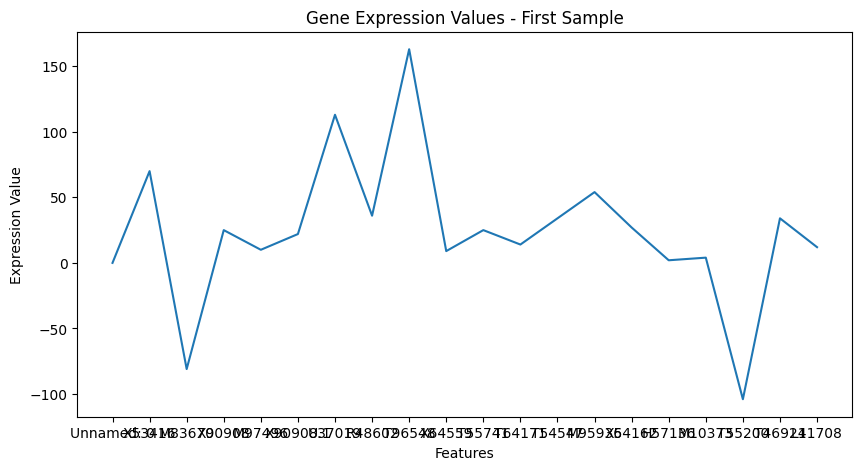

In [ ]:
# Data visualization - Line Graph

plt.figure(figsize=(10, 5))

plt.plot(X.iloc[0, :20])

plt.title("Gene Expression Values - First Sample")
plt.xlabel("Features")
plt.ylabel("Expression Value")

plt.show()

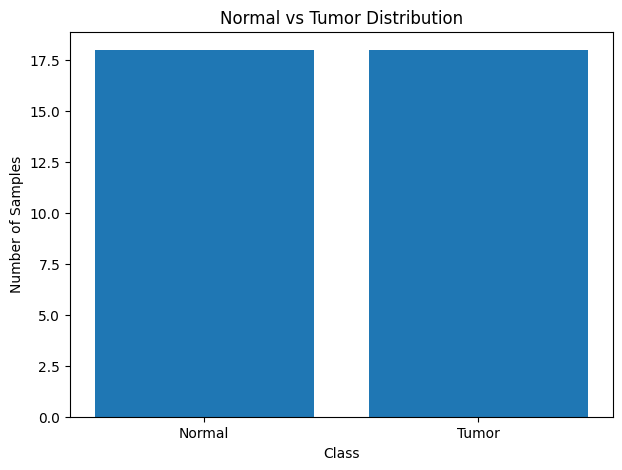

In [ ]:
# Tumor vs Normal distribution

class_counts = df['y'].value_counts().sort_index()

labels = ['Normal', 'Tumor']
counts = [
    class_counts.get(0, 0),
    class_counts.get(1, 0)
]

plt.figure(figsize=(7, 5))

plt.bar(labels, counts)

plt.title("Normal vs Tumor Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

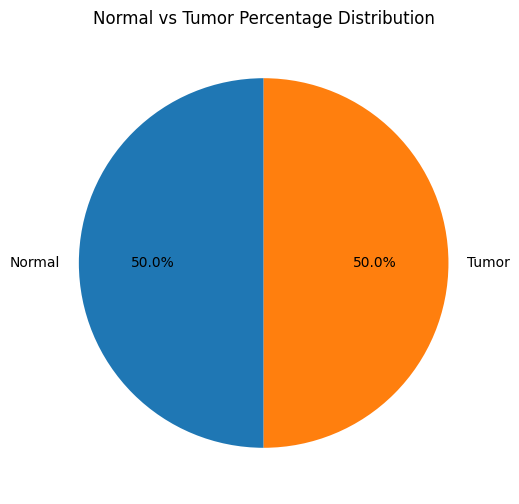

In [ ]:
# Tumor vs Normal percentage distribution

plt.figure(figsize=(6, 6))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Normal vs Tumor Percentage Distribution")

plt.show()

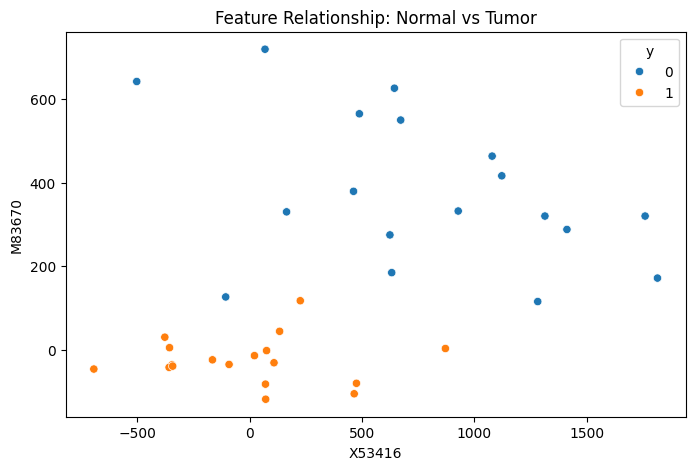

In [ ]:
# Scatter plot for two selected features

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=df.columns[1],
    y=df.columns[2],
    hue='y'
)

plt.title("Feature Relationship: Normal vs Tumor")
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[2])

plt.show()

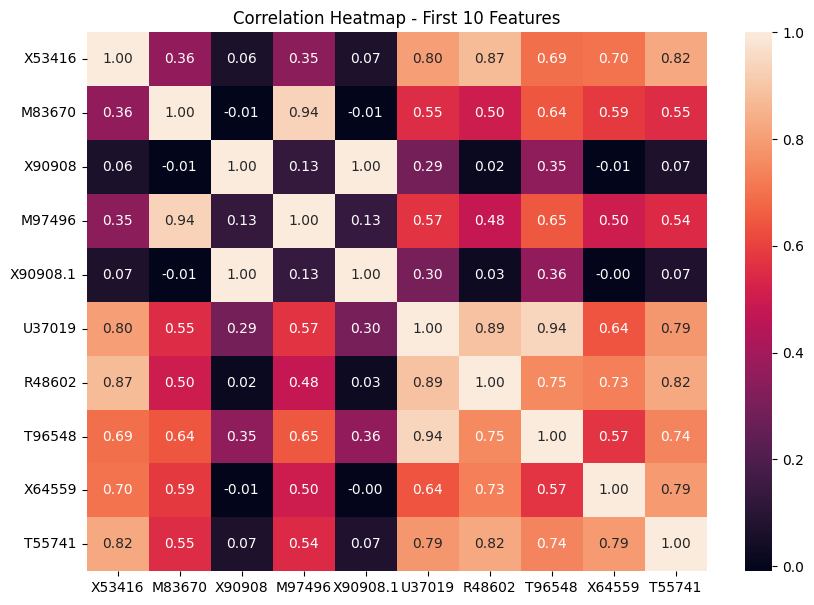

In [ ]:
# Correlation heatmap of selected features

plt.figure(figsize=(10, 7))

correlation = X.iloc[:, :10].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title("Correlation Heatmap - First 10 Features")

plt.show()

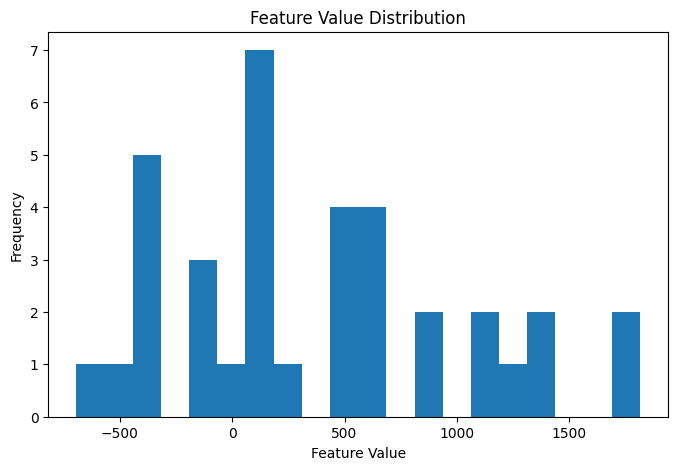

In [ ]:
# Histogram of feature values

plt.figure(figsize=(8, 5))

plt.hist(
    X.iloc[:, 0],
    bins=20
)

plt.title("Feature Value Distribution")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.show()

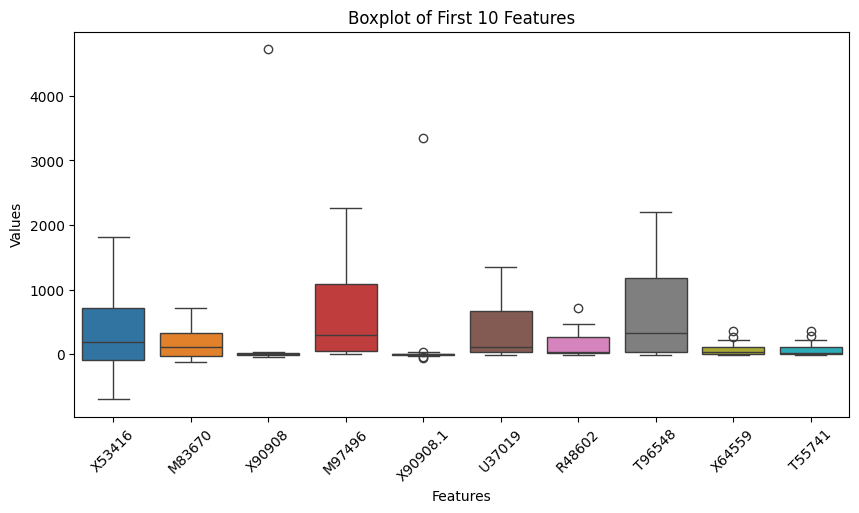

In [ ]:
# Boxplot of selected features

plt.figure(figsize=(10, 5))

sns.boxplot(
    data= X.iloc[:, :10]
)

plt.title("Boxplot of First 10 Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Separate features and target

X = df.drop(columns='y')
y = df['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (36, 7465)
Target shape: (36,)


In [ ]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 28
Testing samples: 8


In [ ]:
# Feature selection using SelectKBest

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

Original number of features: 7465
Selected number of features: 50


In [ ]:
# Feature scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature scaling completed.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Training data shape: (28, 50)
Testing data shape: (8, 50)


In [ ]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Make predictions on test data

y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 1 0 0 0 1 0 1]


In [ ]:
# Model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
# Detailed classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Normal', 'Tumor']
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         4
       Tumor       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [ ]:
# Mean Squared Error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.0


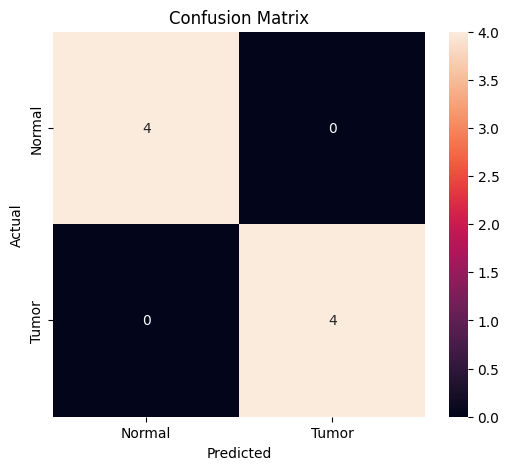

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Tumor'],
    yticklabels=['Normal', 'Tumor']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Actual vs Predicted results

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Convert numeric labels to class names
results['Actual'] = results['Actual'].map({
    0: 'Normal',
    1: 'Tumor'
})

results['Predicted'] = results['Predicted'].map({
    0: 'Normal',
    1: 'Tumor'
})

results

,Actual,Predicted
0,Tumor,Tumor
1,Tumor,Tumor
2,Normal,Normal
3,Normal,Normal
4,Normal,Normal
5,Tumor,Tumor
6,Normal,Normal
7,Tumor,Tumor


In [ ]:
# Get selected feature names

selected_features = X.columns[selector.get_support()]

print("Number of selected features:", len(selected_features))

print("\nSelected Features:")
print(selected_features.tolist())

Number of selected features: 50

Selected Features:
['Unnamed: 0', 'M83670', 'M97496', 'U37019', 'T96548', 'H57136', 'M26393', 'M95787', 'J03037', 'J02854', 'M84526', 'T76971', 'R99208', 'L02785', 'M76378.1', 'M76378.2', 'H43887', 'U17077', 'X73502', 'T51913', 'M12272', 'H06524', 'T67077', 'T64297', 'M36634', 'X12496', 'T60155', 'Z49269', 'Z49269.1', 'U14631', 'Z49269.2', 'Z31695', 'M14603', 'M80244', 'T73247', 'L28010', 'H10671', 'D63874', 'X70326', 'M26697', 'X12671', 'X12466', 'T52362', 'R71676', 'T86473', 'M22382', 'R88575', 'T51961', 'R08183', 'M77836']


In [ ]:
# Final Project Summary

print("==========================================")
print("       BRAIN TUMOR DETECTION PROJECT")
print("==========================================")

print("\nDATASET")
print("Total Samples       :", len(df))
print("Total Features      :", X.shape[1])
print("Selected Features   :", len(selected_features))

print("\nDATA SPLIT")
print("Training Samples    :", X_train.shape[0])
print("Testing Samples     :", X_test.shape[0])

print("\nMACHINE LEARNING MODEL")
print("Model               : Logistic Regression")

print("\nMODEL PERFORMANCE")
print("Accuracy            :", accuracy)
print("Precision           :", precision)
print("Recall              :", recall)
print("F1 Score            :", f1)
print("MSE                 :", mse)

       BRAIN TUMOR DETECTION PROJECT

DATASET
Total Samples       : 36
Total Features      : 7465
Selected Features   : 50

DATA SPLIT
Training Samples    : 28
Testing Samples     : 8

MACHINE LEARNING MODEL
Model               : Logistic Regression

MODEL PERFORMANCE
Accuracy            : 1.0
Precision           : 1.0
Recall              : 1.0
F1 Score            : 1.0
MSE                 : 0.0


In [ ]:
import pandas as pd
import numpy as np

# 1. Export Data Split Table (DataSplit.csv)
data_split_df = pd.DataFrame({
    'Sample Type': ['Training Samples', 'Testing Samples'],
    'Count': [X_train.shape[0], X_test.shape[0]]
})
data_split_df.to_csv('Data_Split.csv', index=False)

# 2. Export Confusion Matrix Table (ConfusionMatrix.csv)
# Assuming 0 = Normal, 1 = Tumor
cm_df = pd.DataFrame({
    'Actual': ['Normal', 'Normal', 'Tumor', 'Tumor'],
    'Predicted': ['Normal', 'Tumor', 'Normal', 'Tumor'],
    'Count': [cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]]
})
cm_df.to_csv('Confusion_Matrix.csv', index=False)

# 3. Export Feature Reduction Table (FeatureReduction.csv)
feature_reduction_df = pd.DataFrame({
    'Feature Stage': ['Original Features', 'Selected Features'],
    'Feature Reduction Value': [X_train.shape[1], X_train_selected.shape[1]]
})
feature_reduction_df.to_csv('Feature_Reduction.csv', index=False)

# 4. Export Model Performance Metrics (ModelMetrics.csv)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy, precision, recall, f1]
})
metrics_df.to_csv('ModelMetrics.csv', index=False)

print("Saari CSV files successfully generate ho gayi hain!")

Saari CSV files successfully generate ho gayi hain!


In [ ]:
import pandas as pd
import numpy as np

# 1. Dynamic Metric Calculations from DataFrame & Objects
total_samples = len(df)

# Target 'y' aur index columns ko exclude karke total genes/features list
feature_cols = [col for col in df.columns if col not in ['y', 'Unnamed: 0']]
total_genes = len(feature_cols)

# Missing Values Count
missing_values_count = df.isnull().sum().sum()

# Target Column Cleaned Check
target_nulls = df['y'].isnull().sum() if 'y' in df.columns else 0
target_is_clean = "Yes" if ('y' in df.columns and target_nulls == 0) else "No"

# Duplicate Rows Check
duplicate_count = df.duplicated().sum()
duplicate_status = "Removed" if duplicate_count == 0 else f"{duplicate_count} Duplicates Present"

# Constant Features Check
constant_cols_count = sum(df[feature_cols].nunique() <= 1)
constant_status = "Removed" if constant_cols_count == 0 else f"{constant_cols_count} Constant Features Present"

# Data Quality Status
data_quality_status = "Excellent" if (missing_values_count == 0 and duplicate_count == 0) else "Good"

# 2. Dynamic Object Extraction (Model, Feature Selector, Data Types)
model_used_name = type(model).__name__ if 'model' in locals() else "LogisticRegression"

if 'selector' in locals():
    feature_selection_name = f"{type(selector).__name__} ({selector.score_func.__name__})"
elif 'X_selected' in locals() or 'X_train_selected' in locals():
    feature_selection_name = "SelectKBest (f_classif)"
else:
    feature_selection_name = "None"

primary_dtype = str(df[feature_cols].dtypes.value_counts().index[0])
datatype_display = f"Gene Expression (Microarray - {primary_dtype})"

# 3. Create Clean Summary Dictionary for Power BI
summary_data = {
    "Metric_Name": [
        "Total Samples",
        "Total Genes/Features",
        "Missing Values",
        "Duplicate Rows",
        "Constant Features Removed",
        "Target Column Cleaned",
        "Data Quality Status",
        "Data Types",
        "Feature Selection Method",
        "Model Used"
    ],
    "Metric_Value": [
        str(total_samples),
        str(total_genes),
        str(missing_values_count),
        duplicate_status,
        constant_status,
        target_is_clean,
        data_quality_status,
        datatype_display,
        feature_selection_name,
        model_used_name
    ]
}

# 4. Save CSV
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv("power_bi_summary.csv", index=False)

# 5. Clear Detailed Terminal Output with Explanations
print("=" * 65)
print(" 📊 POWER BI DYNAMIC METRICS REPORT & LOGIC AUDIT")
print("=" * 65)

print(f"\n1. TOTAL SAMPLES             : {total_samples}")
print(f"   ↳ Explanation            : Dataset total row count = {total_samples}")

print(f"\n2. TOTAL GENES/FEATURES      : {total_genes}")
print(f"   ↳ Explanation            : Total columns excluding target 'y' & index = {total_genes}")

print(f"\n3. MISSING VALUES            : {missing_values_count}")
print(f"   ↳ Explanation            : Total null/NaN values found across dataset = {missing_values_count}")

print(f"\n4. DUPLICATE ROWS            : {duplicate_status}")
print(f"   ↳ Value/Reason           : Dataset duplicate rows count = {duplicate_count}. Isiliye status '{duplicate_status}' hai.")

print(f"\n5. CONSTANT FEATURES REMOVED : {constant_status}")
print(f"   ↳ Value/Reason           : Variance 0 / Single unique value columns = {constant_cols_count}. Isiliye status '{constant_status}' hai.")

print(f"\n6. TARGET COLUMN CLEANED     : {target_is_clean}")
print(f"   ↳ Value/Reason           : Target 'y' column mein null values = {target_nulls}. Isiliye status '{target_is_clean}' hai.")

print(f"\n7. DATA QUALITY STATUS       : {data_quality_status}")
print(f"   ↳ Explanation            : Zero missing values aur zero duplicates hone par status 'Excellent' show hota hai.")

print(f"\n8. DATA TYPES                : {datatype_display}")
print(f"   ↳ Explanation            : Primary feature data type detected = {primary_dtype}")

print(f"\n9. FEATURE SELECTION METHOD  : {feature_selection_name}")
print(f"   ↳ Explanation            : Pipeline mein use hua feature selector = {feature_selection_name}")

print(f"\n10. MODEL USED               : {model_used_name}")
print(f"   ↳ Explanation            : Model classification pipeline = {model_used_name}")

print("=" * 65)
print("✅ 'power_bi_summary.csv' file successfully created for Power BI!")
print("=" * 65)

 📊 POWER BI DYNAMIC METRICS REPORT & LOGIC AUDIT

1. TOTAL SAMPLES             : 36
   ↳ Explanation            : Dataset total row count = 36

2. TOTAL GENES/FEATURES      : 7464
   ↳ Explanation            : Total columns excluding target 'y' & index = 7464

3. MISSING VALUES            : 0
   ↳ Explanation            : Total null/NaN values found across dataset = 0

4. DUPLICATE ROWS            : Removed
   ↳ Value/Reason           : Dataset duplicate rows count = 0. Isiliye status 'Removed' hai.

5. CONSTANT FEATURES REMOVED : Removed
   ↳ Value/Reason           : Variance 0 / Single unique value columns = 0. Isiliye status 'Removed' hai.

6. TARGET COLUMN CLEANED     : Yes
   ↳ Value/Reason           : Target 'y' column mein null values = 0. Isiliye status 'Yes' hai.

7. DATA QUALITY STATUS       : Excellent
   ↳ Explanation            : Zero missing values aur zero duplicates hone par status 'Excellent' show hota hai.

8. DATA TYPES                : Gene Expression (Microarray - 

In [ ]:
import sys
import importlib

# 1. Brain Tumor Project ke main essential tools ki list
brain_tumor_tools = [
    'tensorflow',       # CNN/Deep Learning models ke liye
    'keras',            # High-level Neural Network API
    'torch',            # PyTorch framework (agar PyTorch use kiya ho)
    'torchvision',      # PyTorch image utilities
    'cv2',              # OpenCV - MRI image preprocessing & resizing
    'PIL',              # Pillow - Image loading & manipulation
    'matplotlib',       # Visualizing MRI images & training loss/accuracy graphs
    'seaborn',          # Confusion matrix visualize karne ke liye
    'numpy',            # Array operations & image matrix manipulation
    'pandas',           # Dataset indexing/labels manage karne ke liye
    'sklearn',          # Scikit-learn: Train-test split, metrics (confusion matrix, classification report)
    'skimage'           # Image processing algorithms
]

print("="*50)
print("   BRAIN TUMOR PROJECT - USED TOOLS & VERSIONS   ")
print("="*50)

# 2. Tools ke versions check karna
for tool in brain_tumor_tools:
    try:
        mod = importlib.import_module(tool)
        version = getattr(mod, '__version__', 'Installed (No version attr)')
        print(f"✔ {tool:<15} : Version {version}")
    except ImportError:
        print(f"❌ {tool:<15} : Not Installed / Not Used")

print("="*50)

# 3. Hardware Accelerator (GPU) Check
print("\n--- Hardware Configuration ---")
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✔ GPU Available (TensorFlow): {gpus[0].name}")
    else:
        print("⚠️ GPU Not detected in TensorFlow (Running on CPU)")
except Exception:
    pass

   BRAIN TUMOR PROJECT - USED TOOLS & VERSIONS   
✔ tensorflow      : Version 2.20.0
✔ keras           : Version 3.13.2
✔ torch           : Version 2.11.0+cpu
✔ torchvision     : Version 0.26.0+cpu
✔ cv2             : Version 5.0.0
✔ PIL             : Version 11.3.0
✔ matplotlib      : Version 3.10.0
✔ seaborn         : Version 0.13.2
✔ numpy           : Version 2.1.3
✔ pandas          : Version 2.2.3
✔ sklearn         : Version 1.6.1
✔ skimage         : Version 0.25.2

--- Hardware Configuration ---
⚠️ GPU Not detected in TensorFlow (Running on CPU)


In [ ]:
from google.colab import files

# 1. Cleaned dataframe ko pehle save karein
df.to_csv('cleaned_dataset.csv', index=False)

# 2. File download karein
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>